## Phase 1 - Accuracy Refactor Overview

**Official Validation-Only Presentation.** This notebook evaluates the architectures and configurations trained during the Validation-Only Accuracy Refactor experiment (`05_accuracy_refactor.ipynb`).

**Goal:** Present the experiment lineage, configuration comparisons, overfitting diagnostics, and final validation metrics for the selected strategy without exposing or evaluating the Test set.

## Phase 2 - Artifact Lineage
Resolving the project environment, loading persisted V3 artifacts, and injecting Notebook 4's presentation theme.

In [1]:

import json
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Project Resolution
working_root = Path.cwd().resolve()
project_candidates = (
    working_root,
    working_root.parent,
    working_root / "total_practice/practice_2_2",
)
project_root = next(
    (
        candidate
        for candidate in project_candidates
        if (candidate / "src/practice_2_2").is_dir()
    ),
    None,
)
if project_root is None:
    raise RuntimeError("Cannot locate the Practice 2.2 project root")
source_root = project_root / "src"
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

import practice_2_2.visualization_utils as vu
vu.inject_theme_css()

# Artifact Lineage
ARTIFACT_ROOT = (project_root / "artifacts/new_work/accuracy_refactor_validation_only_v1").resolve()
assert ARTIFACT_ROOT.exists(), f"Artifact root {ARTIFACT_ROOT} not found! Run Notebook 5 first."

manifest_path = project_root / "data/manifests/canonical_split/split_manifest_v3_format.csv"
dataset_root = project_root / "data/final/data_clean_balanced"

def load_json_required(filepath):
    p = Path(filepath)
    if not p.exists():
        raise FileNotFoundError(f"Required artifact {p.name} is missing!")
    with open(p) as f:
        return json.load(f)

summary_data = load_json_required(ARTIFACT_ROOT / "repeated_seed_summary.json")
selection_data = load_json_required(ARTIFACT_ROOT / "validation_inference_selection.json")

lineage_table = pd.DataFrame([
    ["Artifact Root", str(ARTIFACT_ROOT)],
    ["Manifest Used", str(manifest_path.name)],
    ["Dataset Root", str(dataset_root.name)]
], columns=["Component", "Path"])
display(vu.style_generic_table(lineage_table).hide(axis="index").set_caption("Artifact Lineage"))


Component,Path
Artifact Root,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_2_2/artifacts/new_work/accuracy_refactor_validation_only_v1
Manifest Used,split_manifest_v3_format.csv
Dataset Root,data_clean_balanced


## Phase 3 - Dataset / Manifest Used

In [2]:

manifest = pd.read_csv(manifest_path)
model_use = manifest[manifest['use_for_model'] == True]

split_counts = model_use['split'].value_counts().reindex(["Train", "Validation", "Test"])
display(vu.render_summary_cards([
    ("Train", f"{split_counts['Train']:,}", "ACTIVE", "primary"),
    ("Validation", f"{split_counts['Validation']:,}", "ACTIVE", "primary"),
    ("Test", f"{split_counts['Test']:,}", "LOCKED", "danger"),
    ("Total", f"{split_counts.sum():,}", "ORIGINALS", "muted")
]))


## Phase 4 - Validation-Only Evaluation Policy

In [3]:

test_evaluated = selection_data.get("test_evaluated", False)
assert test_evaluated is False, "Safety Assertion Failed: test_evaluated must be False for this Validation-only report."

display(Markdown("> [!IMPORTANT]\n> **VALIDATION-ONLY EVALUATION POLICY**\n> This notebook exclusively uses the Validation split for model selection, ensemble voting, and metric reporting. The Test DataLoader is NOT constructed, and the Test set remains untouched to prevent data leakage."))


> [!IMPORTANT]
> **VALIDATION-ONLY EVALUATION POLICY**
> This notebook exclusively uses the Validation split for model selection, ensemble voting, and metric reporting. The Test DataLoader is NOT constructed, and the Test set remains untouched to prevent data leakage.

## Phase 5 - Architectures & Configurations

In [4]:

configs = []
for s in summary_data['summaries']:
    c = s['config']
    configs.append({
        "Configuration ID": s['configuration_id'],
        "Architecture": c['architecture'],
        "Label Smoothing": c['label_smoothing'],
        "Batch Size": c['batch_size'],
        "Dropout": c['dropout'],
        "Warmup Epochs": c['warmup_epochs'],
        "Finetune Epochs": c['finetune_epochs']
    })

config_df = pd.DataFrame(configs)
display(vu.style_generic_table(config_df).hide(axis="index").set_caption("Experiment Configurations"))


Configuration ID,Architecture,Label Smoothing,Batch Size,Dropout,Warmup Epochs,Finetune Epochs
resnet18_ls0p0_754563edcc24,resnet18,0.000000,32,0.350000,4,18
resnet18_ls0p05_fc7166324b66,resnet18,0.050000,32,0.350000,4,18
efficientnet_b0_ls0p05_40e072356938,efficientnet_b0,0.050000,32,0.350000,4,18
efficientnet_b0_ls0p0_b6341fc24245,efficientnet_b0,0.000000,32,0.350000,4,18


## Phase 6 - Repeated Seed Results

In [5]:

summary_records = []
for s in summary_data['summaries']:
    config = s['config']
    
    summary_records.append({
        "Architecture": config['architecture'],
        "Label Smoothing": config['label_smoothing'],
        "Seed Count": s['seed_count'],
        "Mean Val Accuracy": f"{s['mean_validation_accuracy']*100:.2f}%",
        "Std Val Accuracy": f"{s['std_validation_accuracy']:.4f}",
        "Mean Val Macro F1": f"{s['mean_validation_macro_f1']:.4f}",
        "Std Val Macro F1": f"{s['std_validation_macro_f1']:.4f}",
    })

seed_df = pd.DataFrame(summary_records)
display(vu.style_generic_table(seed_df).hide(axis="index").set_caption("Repeated Seed Results (Aggregated from JSON)"))
display(Markdown("> **Note:** The aggregated repeated_seed_summary.json does not contain `mean_train_accuracy` natively."))


Architecture,Label Smoothing,Seed Count,Mean Val Accuracy,Std Val Accuracy,Mean Val Macro F1,Std Val Macro F1
resnet18,0.000000,3,69.71%,0.0086,0.6933,0.0087
resnet18,0.050000,3,69.33%,0.0103,0.6895,0.0096
efficientnet_b0,0.050000,3,67.35%,0.0068,0.6695,0.0072
efficientnet_b0,0.000000,3,67.20%,0.0073,0.6678,0.0073


> **Note:** The aggregated repeated_seed_summary.json does not contain `mean_train_accuracy` natively.

## Phase 7 - Single-Model Comparison & Overfitting Diagnostics

In [6]:

all_runs = []
overfit_analysis = []

selected = selection_data['selected']
ensemble_paths = [Path(p).parent.name for p in selected['checkpoint_paths']]

best_single_acc = 0.0
best_single_run = None

for result in summary_data['results']:
    best_metrics = result['finetune_best']
    train_metrics = best_metrics.get('train_metrics', {})
    
    val_acc = best_metrics.get('accuracy', 0.0)
    val_loss = best_metrics.get('loss', 0.0)
    val_f1 = best_metrics.get('macro_f1', 0.0)
    
    train_acc = train_metrics.get('accuracy', None)
    train_loss = train_metrics.get('loss', None)
    
    # Track best single run
    if val_acc > best_single_acc:
        best_single_acc = val_acc
        best_single_run = result
    
    path_name = Path(result['checkpoint_path']).parent.name
    role = "ENSEMBLE MEMBER" if path_name in ensemble_paths else "SINGLE MODEL CANDIDATE"
    
    if train_acc is not None:
        gap = (train_acc - val_acc) * 100
        gap_str = f"{gap:.2f}"
        train_acc_str = f"{train_acc*100:.2f}%"
        train_loss_str = f"{train_loss:.4f}"
        
        # Assessment logic
        if gap < 5:
            assessment = "LOW GAP"
        elif gap < 10:
            assessment = "MODERATE GAP"
        elif gap < 20:
            assessment = "HIGH GAP"
        else:
            assessment = "VERY HIGH GAP"
            
        if train_acc < 0.60 and val_acc < 0.60:
            assessment += " (POSSIBLE UNDERFITTING)"
        elif train_acc > 0.90 and gap > 15:
            assessment += " (POSSIBLE OVERFITTING)"
            
    else:
        gap = None
        gap_str = "N/A"
        train_acc_str = "N/A"
        train_loss_str = "N/A"
        assessment = "N/A"
    config_id = Path(result['checkpoint_path']).parent.parent.name
    ls_val = next((s['config']['label_smoothing'] for s in summary_data['summaries'] if s['configuration_id'] == config_id), "N/A")

    all_runs.append({
        "Architecture": result['architecture'],
        "Label Smoothing": ls_val,
        "Seed": result['seed'],
        "Train Accuracy": train_acc_str,
        "Train Loss": train_loss_str,
        "Validation Accuracy": f"{val_acc*100:.2f}%",
        "Validation Loss": f"{val_loss:.4f}",
        "Validation Macro F1": f"{val_f1:.4f}",
        "Generalization Gap (pp)": gap_str,
        "Checkpoint": path_name,
        "Role": role
    })
    
    overfit_analysis.append({
        "Architecture": result['architecture'],
        "Label Smoothing": ls_val,
        "Seed": result['seed'],
        "Train Acc": train_acc_str,
        "Val Acc": f"{val_acc*100:.2f}%",
        "Gap (pp)": gap_str,
        "Assessment": assessment
    })

runs_df = pd.DataFrame(all_runs)

def highlight_selected(s):
    return ['background-color: var(--success-bg); color: var(--success-text); font-weight: bold' if v == 'ENSEMBLE MEMBER' else '' for v in s]

styler = vu.style_generic_table(runs_df).hide(axis="index").set_caption("Single-Model Comparison")
display(styler.apply(highlight_selected, subset=['Role']))

overfit_df = pd.DataFrame(overfit_analysis)
display(vu.style_generic_table(overfit_df).hide(axis="index").set_caption("OVERFITTING ANALYSIS (Descriptive Diagnostic)"))
display(Markdown("> *Note: This analysis strictly uses Train ↔ Validation. It is a descriptive diagnostic and not the final model selection criterion.*"))


Architecture,Label Smoothing,Seed,Train Accuracy,Train Loss,Validation Accuracy,Validation Loss,Validation Macro F1,Generalization Gap (pp),Checkpoint,Role
resnet18,0.000000,42,87.80%,0.4453,70.09%,0.9948,0.6985,17.71,seed_42,ENSEMBLE MEMBER
resnet18,0.000000,123,97.17%,0.1750,70.32%,1.0281,0.6980,26.85,seed_123,ENSEMBLE MEMBER
resnet18,0.000000,2026,96.88%,0.1752,68.72%,0.9984,0.6833,28.15,seed_2026,SINGLE MODEL CANDIDATE
resnet18,0.050000,42,86.16%,0.7300,69.41%,1.1828,0.6933,16.75,seed_42,ENSEMBLE MEMBER
resnet18,0.050000,123,96.33%,0.4818,70.32%,1.1729,0.6966,26.01,seed_123,ENSEMBLE MEMBER
resnet18,0.050000,2026,95.98%,0.4797,68.26%,1.1637,0.6785,27.72,seed_2026,SINGLE MODEL CANDIDATE
efficientnet_b0,0.000000,42,79.37%,0.6992,68.04%,0.9744,0.6761,11.33,seed_42,ENSEMBLE MEMBER
efficientnet_b0,0.000000,123,80.01%,0.6904,66.89%,0.9706,0.6645,13.11,seed_123,ENSEMBLE MEMBER
efficientnet_b0,0.000000,2026,80.06%,0.6958,66.67%,0.9607,0.6626,13.39,seed_2026,SINGLE MODEL CANDIDATE
efficientnet_b0,0.050000,42,81.94%,0.8532,68.04%,1.1174,0.6772,13.91,seed_42,ENSEMBLE MEMBER


Architecture,Label Smoothing,Seed,Train Acc,Val Acc,Gap (pp),Assessment
resnet18,0.000000,42,87.80%,70.09%,17.71,HIGH GAP
resnet18,0.000000,123,97.17%,70.32%,26.85,VERY HIGH GAP (POSSIBLE OVERFITTING)
resnet18,0.000000,2026,96.88%,68.72%,28.15,VERY HIGH GAP (POSSIBLE OVERFITTING)
resnet18,0.050000,42,86.16%,69.41%,16.75,HIGH GAP
resnet18,0.050000,123,96.33%,70.32%,26.01,VERY HIGH GAP (POSSIBLE OVERFITTING)
resnet18,0.050000,2026,95.98%,68.26%,27.72,VERY HIGH GAP (POSSIBLE OVERFITTING)
efficientnet_b0,0.000000,42,79.37%,68.04%,11.33,HIGH GAP
efficientnet_b0,0.000000,123,80.01%,66.89%,13.11,HIGH GAP
efficientnet_b0,0.000000,2026,80.06%,66.67%,13.39,HIGH GAP
efficientnet_b0,0.050000,42,81.94%,68.04%,13.91,HIGH GAP


> *Note: This analysis strictly uses Train ↔ Validation. It is a descriptive diagnostic and not the final model selection criterion.*

## Phase 8 - Visualization: Train vs Validation Performance

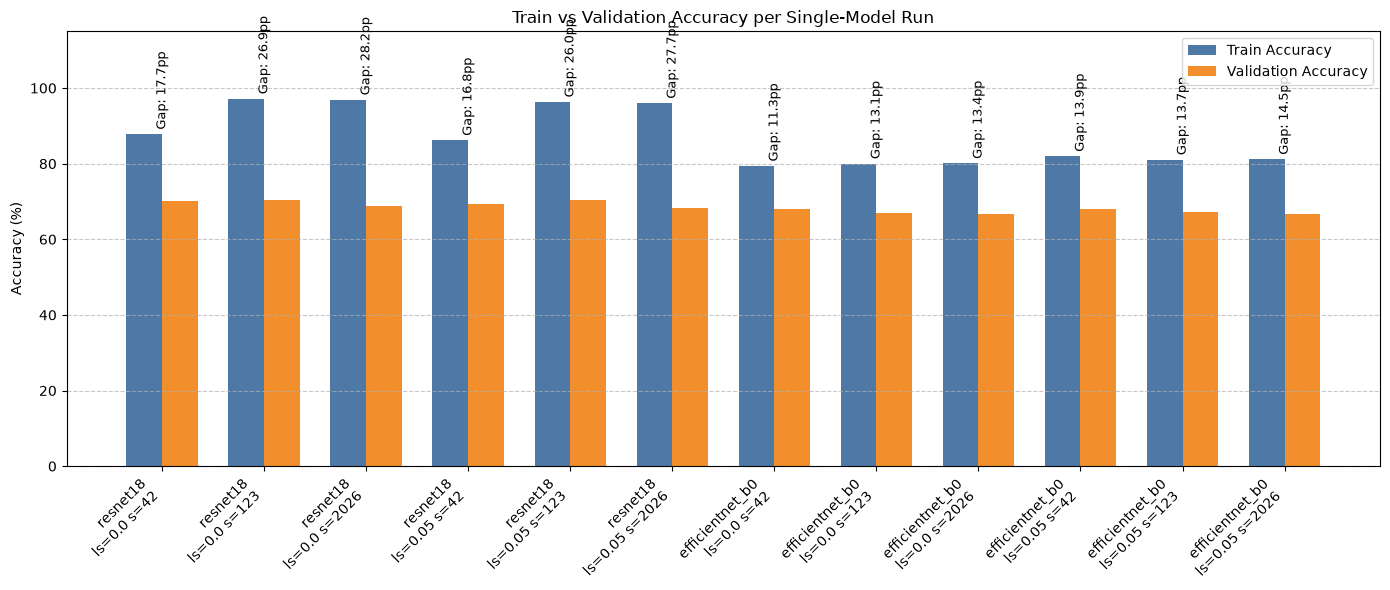

In [7]:

valid_runs = [r for r in all_runs if r['Train Accuracy'] != 'N/A']
if len(valid_runs) > 0:
    labels = [f"{r['Architecture']}\nls={r['Label Smoothing']} s={r['Seed']}" for r in valid_runs]
    train_accs = [float(r['Train Accuracy'].strip('%')) for r in valid_runs]
    val_accs = [float(r['Validation Accuracy'].strip('%')) for r in valid_runs]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Theme-aware plotting (using current matplotlib rc params which might be light/dark)
    rects1 = ax.bar(x - width/2, train_accs, width, label='Train Accuracy', color='#4e79a7')
    rects2 = ax.bar(x + width/2, val_accs, width, label='Validation Accuracy', color='#f28e2b')

    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Train vs Validation Accuracy per Single-Model Run')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Add gap annotations
    for i in range(len(valid_runs)):
        gap = train_accs[i] - val_accs[i]
        ax.text(x[i], max(train_accs[i], val_accs[i]) + 2, f"Gap: {gap:.1f}pp", ha='center', fontsize=9, rotation=90)

    ax.set_ylim(0, 115)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("No Training Accuracy data available to plot."))


## Phase 9 - Selected Ensemble Strategy

In [8]:

display(Markdown(f"### Final Selected Validation Strategy: ENSEMBLE ({selected['member_count']} Models)"))
display(Markdown(f"- **TTA Scales used**: {selected['tta_scales']}"))
display(Markdown("#### MEMBER METRICS"))

member_df_data = []
for m in valid_runs:
    if m['Role'] == 'ENSEMBLE MEMBER':
        member_df_data.append({
            "Ensemble Member": f"{m['Architecture']} (s={m['Seed']})",
            "Train Acc": m['Train Accuracy'],
            "Val Acc": m['Validation Accuracy'],
            "Gap (pp)": m['Generalization Gap (pp)']
        })
        
if member_df_data:
    display(vu.style_generic_table(pd.DataFrame(member_df_data)).hide(axis="index").set_caption("Individual Member Diagnostics"))

display(Markdown("> **Note:** The selected ensemble strategy is formed from validation predictions. Train-level ensemble metrics were not persisted by the current accuracy-refactor pipeline. Thus, there is NO Ensemble Train Accuracy or Generalization Gap."))


### Final Selected Validation Strategy: ENSEMBLE (2 Models)

- **TTA Scales used**: [1.0]

#### MEMBER METRICS

Ensemble Member,Train Acc,Val Acc,Gap (pp)
resnet18 (s=42),87.80%,70.09%,17.71
resnet18 (s=123),97.17%,70.32%,26.85
resnet18 (s=42),86.16%,69.41%,16.75
resnet18 (s=123),96.33%,70.32%,26.01
efficientnet_b0 (s=42),79.37%,68.04%,11.33
efficientnet_b0 (s=123),80.01%,66.89%,13.11
efficientnet_b0 (s=42),81.94%,68.04%,13.91
efficientnet_b0 (s=123),81.05%,67.35%,13.70


> **Note:** The selected ensemble strategy is formed from validation predictions. Train-level ensemble metrics were not persisted by the current accuracy-refactor pipeline. Thus, there is NO Ensemble Train Accuracy or Generalization Gap.

## Phase 10 - Summary Cards

In [9]:

metrics = selected['validation_metrics']

val_acc = metrics['accuracy']
macro_f1 = metrics['macro_f1']

# Best Single Run Logic
best_single_train_acc = best_single_run.get('train_metrics', {}).get('accuracy', None)
bst_acc_str = f"{best_single_train_acc*100:.2f}%" if best_single_train_acc else "N/A"
bst_val_str = f"{best_single_acc*100:.2f}%"
bst_gap_str = f"{(best_single_train_acc - best_single_acc)*100:.2f}pp" if best_single_train_acc else "N/A"

display(Markdown("### BEST SINGLE RUN"))
display(vu.render_summary_cards([
    ("Architecture", best_single_run['architecture'], f"Seed: {best_single_run['seed']}", "info"),
    ("Train Accuracy", bst_acc_str, "METRIC", "info"),
    ("Validation Accuracy", bst_val_str, "METRIC", "success"),
    ("Generalization Gap", bst_gap_str, "DIAGNOSTIC", "warning")
]))

display(Markdown("### FINAL SELECTED STRATEGY"))
display(vu.render_summary_cards([
    ("Strategy", f"Ensemble ({selected['member_count']}x)", "BEST", "primary"),
    ("Validation Accuracy", f"{val_acc*100:.2f}%", "METRIC", "success"),
    ("Validation Macro F1", f"{macro_f1:.4f}", "METRIC", "success"),
    ("Train Accuracy", "N/A", "NO ARTIFACT", "muted"),
    ("TEST STATUS", "NOT EVALUATED", "PENDING", "danger")
]))


### BEST SINGLE RUN

### FINAL SELECTED STRATEGY

## Phase 11 - Training Curves

In [10]:

display(Markdown("### TRAINING CURVES"))
display(Markdown("> [!WARNING]\n> **NOT AVAILABLE**\n> Current accuracy-refactor artifacts do not persist epoch-by-epoch training history."))


### TRAINING CURVES

> [!WARNING]
> **NOT AVAILABLE**
> Current accuracy-refactor artifacts do not persist epoch-by-epoch training history.

## Phase 12 - Validation Confusion Matrix

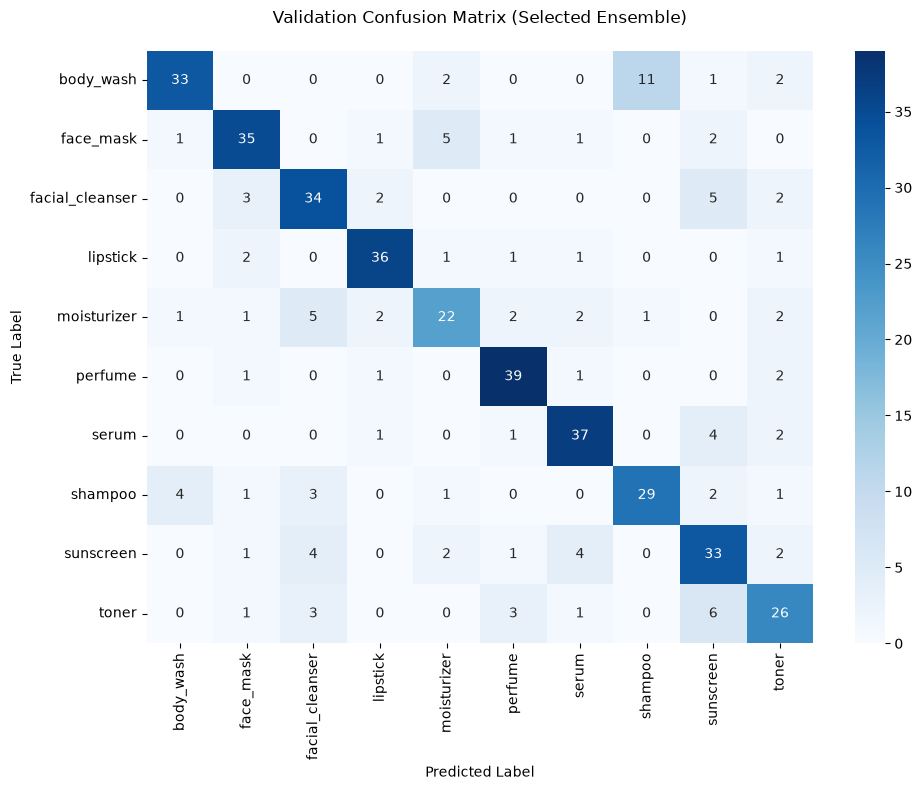

In [11]:

import seaborn as sns

conf_matrix = np.array(metrics['confusion_matrix'])
class_names = sorted(model_use['class_name'].unique())

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Validation Confusion Matrix (Selected Ensemble)", pad=20)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()


## Phase 13 - Validation Per-Class Metrics

In [12]:

per_class = metrics['per_class']

class_records = []
for cls in class_names:
    data = per_class.get(cls, {})
    class_records.append({
        "Class": cls,
        "Precision": f"{data.get('precision', 0):.4f}",
        "Recall": f"{data.get('recall', 0):.4f}",
        "F1 Score": f"{data.get('f1', 0):.4f}",
        "Support": data.get('support', 0)
    })

class_df = pd.DataFrame(class_records)
display(vu.style_generic_table(class_df).hide(axis="index").set_caption("Validation Metrics per Class"))


Class,Precision,Recall,F1 Score,Support
body_wash,0.8462,0.6735,0.7500,49
face_mask,0.7778,0.7609,0.7692,46
facial_cleanser,0.6939,0.7391,0.7158,46
lipstick,0.8372,0.8571,0.8471,42
moisturizer,0.6667,0.5789,0.6197,38
perfume,0.8125,0.8864,0.8478,44
serum,0.7872,0.8222,0.8043,45
shampoo,0.7073,0.7073,0.7073,41
sunscreen,0.6226,0.7021,0.6600,47
toner,0.6500,0.6500,0.6500,40


## Phase 14 - Prediction Gallery

In [13]:

display(Markdown("### PREDICTION GALLERY"))
display(Markdown("> [!WARNING]\n> **NOT AVAILABLE**\n> Current V3 artifacts do not persist per-image prediction outputs."))


### PREDICTION GALLERY

> [!WARNING]
> **NOT AVAILABLE**
> Current V3 artifacts do not persist per-image prediction outputs.

## Phase 15 - Checkpoint / Artifact Verification

In [14]:

display(Markdown("### Checkpoints Confirmed"))
for path in selected['checkpoint_paths']:
    p = Path(path)
    if p.exists():
        display(Markdown(f"- ✅ `{p.parent.name}/{p.name}` exists on disk."))
    else:
        display(Markdown(f"- ❌ `{p.parent.name}/{p.name}` IS MISSING!"))


### Checkpoints Confirmed

- ✅ `seed_123/best_validation.pt` exists on disk.

- ✅ `seed_42/best_validation.pt` exists on disk.

## Phase 16 - Limitations

In [15]:

display(Markdown("- **Validation Only**: Test set is completely untouched. Metrics shown are validation estimates.\n- **Artifact Retention**: Epoch histories and per-image predictions are not currently retained in V3 JSON artifacts, requiring graceful degradation of related visualizations.\n- **Ensemble Inference Cost**: Using multiple models and TTA scales increases inference time multiplicatively."))


- **Validation Only**: Test set is completely untouched. Metrics shown are validation estimates.
- **Artifact Retention**: Epoch histories and per-image predictions are not currently retained in V3 JSON artifacts, requiring graceful degradation of related visualizations.
- **Ensemble Inference Cost**: Using multiple models and TTA scales increases inference time multiplicatively.

## Phase 17 - Train-Validation Generalization Analysis

In [16]:

gaps = [float(r['Generalization Gap (pp)']) for r in all_runs if r['Generalization Gap (pp)'] != 'N/A']
if gaps:
    max_gap_run = max(all_runs, key=lambda x: float(x['Generalization Gap (pp)']) if x['Generalization Gap (pp)'] != 'N/A' else -1)
    min_gap_run = min(all_runs, key=lambda x: float(x['Generalization Gap (pp)']) if x['Generalization Gap (pp)'] != 'N/A' else 999)
    mean_gap = sum(gaps) / len(gaps)
else:
    max_gap_run = min_gap_run = mean_gap = None

display(Markdown("### Overfitting Diagnostic Summary"))
display(Markdown(f"- **Best Single Run Train Accuracy:** {bst_acc_str}"))
display(Markdown(f"- **Best Single Run Val Accuracy:** {bst_val_str}"))
display(Markdown(f"- **Best Single Run Gap:** {bst_gap_str}"))

if gaps:
    display(Markdown(f"- **Mean Generalization Gap (Derived from individual runs):** {mean_gap:.2f} pp"))
    display(Markdown(f"- **Highest Gap Run:** {max_gap_run['Architecture']} s={max_gap_run['Seed']} ({max_gap_run['Generalization Gap (pp)']} pp)"))
    display(Markdown(f"- **Lowest Gap Run:** {min_gap_run['Architecture']} s={min_gap_run['Seed']} ({min_gap_run['Generalization Gap (pp)']} pp)"))

display(Markdown('''
**Assessment Interpretation:**
Generalization Gap is used exclusively to assist in detecting overfitting or underfitting (descriptive diagnostic). **It DOES NOT replace Validation Accuracy / Macro F1 in model selection.** 
The final ensemble selection is derived entirely from validation performance. The Final Ensemble does not have a Train Accuracy because the current pipeline does not persist train-level ensemble inference.
'''))


### Overfitting Diagnostic Summary

- **Best Single Run Train Accuracy:** N/A

- **Best Single Run Val Accuracy:** 70.32%

- **Best Single Run Gap:** N/A

- **Mean Generalization Gap (Derived from individual runs):** 18.59 pp

- **Highest Gap Run:** resnet18 s=2026 (28.15 pp)

- **Lowest Gap Run:** efficientnet_b0 s=42 (11.33 pp)


**Assessment Interpretation:**
Generalization Gap is used exclusively to assist in detecting overfitting or underfitting (descriptive diagnostic). **It DOES NOT replace Validation Accuracy / Macro F1 in model selection.** 
The final ensemble selection is derived entirely from validation performance. The Final Ensemble does not have a Train Accuracy because the current pipeline does not persist train-level ensemble inference.


## Phase 18 - Final Conclusion

In [17]:

display(Markdown(f"**Selected Strategy:** Ensemble of {selected['member_count']} checkpoints with TTA scale {selected['tta_scales']}"))
for p in ensemble_paths:
    display(Markdown(f"- `{p}`"))
display(Markdown(f"**Validation Accuracy:** {val_acc*100:.2f}%"))
display(Markdown(f"**Validation Macro F1:** {macro_f1:.4f}"))
display(Markdown("**Test Evaluation Status:** NOT PERFORMED"))


**Selected Strategy:** Ensemble of 2 checkpoints with TTA scale [1.0]

- `seed_123`

- `seed_42`

**Validation Accuracy:** 73.97%

**Validation Macro F1:** 0.7371

**Test Evaluation Status:** NOT PERFORMED